# Mineração de Dados – Predição de Resultados de Jogos de Futebol Internacional

**Professor:** Marcelo José Siqueira

**Aluno:** Thiago Barbosa de Araújo

**Dataset:** FIFA World Cup 2022 – International Matches ([Kaggle](https://www.kaggle.com/datasets/brenda89/fifa-world-cup-2022))  

**Objetivo:** Prever o resultado do jogo para o time da casa (`Win`, `Draw` ou `Loss`) — tarefa de **classificação multiclasse**.

---

## Escolha da Base de Dados

**1. Qual é o problema que essa base de dados permite investigar?**  
Prever o resultado de uma partida de futebol internacional (vitória, empate ou derrota do time da casa) com base em atributos como ranking FIFA, pontuação FIFA, localização e scores médios por setor de jogo.

**2. A tarefa é de classificação ou regressão? Justifique.**  
Classificação. O atributo alvo (`home_team_result`) possui três categorias discretas: `Win`, `Draw` e `Loss`.

**3. Qual é o atributo alvo (target)?**  
`home_team_result` — indica o resultado do jogo do ponto de vista do time da casa.

---
## Etapa 1: Carregamento e Inspeção Inicial

In [459]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Carregamento do dataset
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "brenda89/fifa-world-cup-2022",
    "international_matches.csv",
)

print(f"Shape: {df.shape}")

Using Colab cache for faster access to the 'fifa-world-cup-2022' dataset.
Shape: (23921, 25)


In [460]:
# Primeiras linhas
df.head()

,date,home_team,away_team,home_team_continent,away_team_continent,home_team_fifa_rank,away_team_fifa_rank,home_team_total_fifa_points,away_team_total_fifa_points,home_team_score,...,shoot_out,home_team_result,home_team_goalkeeper_score,away_team_goalkeeper_score,home_team_mean_defense_score,home_team_mean_offense_score,home_team_mean_midfield_score,away_team_mean_defense_score,away_team_mean_offense_score,away_team_mean_midfield_score
0,1993-08-08,Bolivia,Uruguay,South America,South America,59,22,0,0,3,...,No,Win,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1993-08-08,Brazil,Mexico,South America,North America,8,14,0,0,1,...,No,Draw,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1993-08-08,Ecuador,Venezuela,South America,South America,35,94,0,0,5,...,No,Win,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1993-08-08,Guinea,Sierra Leone,Africa,Africa,65,86,0,0,1,...,No,Win,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1993-08-08,Paraguay,Argentina,South America,South America,67,5,0,0,1,...,No,Lose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [461]:
# Tipos de dados
df.dtypes

,0
date,object
home_team,object
away_team,object
home_team_continent,object
away_team_continent,object
home_team_fifa_rank,int64
away_team_fifa_rank,int64
home_team_total_fifa_points,int64
away_team_total_fifa_points,int64
home_team_score,int64


In [462]:
# Valores ausentes por coluna
ausentes = df.isnull().sum()
ausentes_pct = (ausentes / len(df) * 100).round(2)
pd.DataFrame({'Ausentes': ausentes, '% Ausente': ausentes_pct})[ausentes > 0]

,Ausentes,% Ausente
home_team_goalkeeper_score,15542,64.97
away_team_goalkeeper_score,15826,66.16
home_team_mean_defense_score,16134,67.45
home_team_mean_offense_score,15411,64.42
home_team_mean_midfield_score,15759,65.88
away_team_mean_defense_score,16357,68.38
away_team_mean_offense_score,15609,65.25
away_team_mean_midfield_score,15942,66.64


Porcentagem de Dados Ausentes por Ano (Atributos Técnicos):
year
1993    100.00
1994    100.00
1995    100.00
1996    100.00
1997    100.00
1998    100.00
1999    100.00
2000    100.00
2001    100.00
2002    100.00
2003    100.00
2004     86.22
2005     44.26
2006     44.04
2007     50.33
2008     49.23
2009     42.70
2010     41.65
2011     53.91
2012     49.84
2013     41.40
2014     45.18
2015     52.13
2016     41.41
2017     42.60
2018     43.73
2019     48.65
2020     25.50
2021     39.00
2022     42.21
Name: home_team_mean_offense_score, dtype: float64


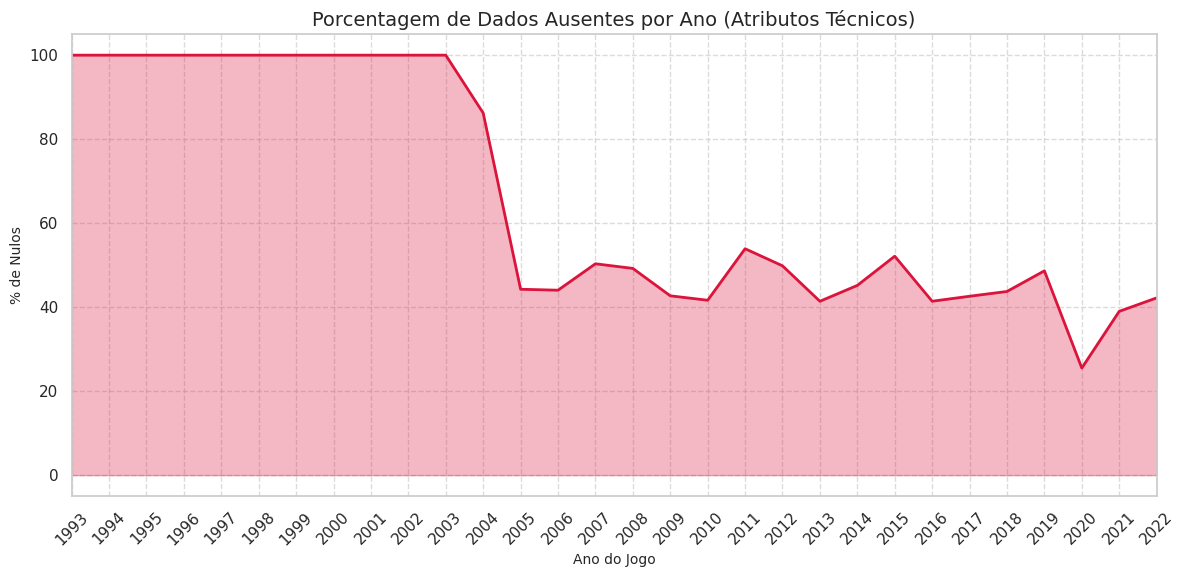

In [463]:
# Valores ausentes por Ano
df['date'] = pd.to_datetime(df['date'])

# Criar uma coluna temporária apenas com o ano
df['year'] = df['date'].dt.year

# Calcular a porcentagem de nulos por ano para a coluna de score de ataque
nulos_por_ano = df.groupby('year')['home_team_mean_offense_score'].apply(lambda x: x.isnull().mean() * 100)

print("Porcentagem de Dados Ausentes por Ano (Atributos Técnicos):")
print(nulos_por_ano.round(2))

# Plotar o gráfico para  a distribuição temporal
plt.figure(figsize=(14, 6))
sns.lineplot(x=nulos_por_ano.index, y=nulos_por_ano.values, color='crimson', linewidth=2)
plt.fill_between(nulos_por_ano.index, nulos_por_ano.values, color='crimson', alpha=0.3)

plt.title('Porcentagem de Dados Ausentes por Ano (Atributos Técnicos)', fontsize=14)
plt.ylabel('% de Nulos', fontsize=10)
plt.xlabel('Ano do Jogo', fontsize=10)
plt.xlim(df['year'].min(), df['year'].max())
plt.grid(True, linestyle='--', alpha=0.7)

plt.xticks(nulos_por_ano.index, rotation=45)

plt.show()

### Respostas – Etapa 1

**1. Quantos atributos e instâncias existem na base?**  
23.921 instâncias e 25 atributos.

**2. Existem valores ausentes? Em quais atributos?**  
Sim. Os atributos relacionados a scores de goleiros, defesa, ataque e meio-campo possuem entre  64.42%  e 68.38% de valores ausentes, pois esse dado não está disponível para todos os períodos históricos cobertos.

**3. Todos os atributos possuem tipos adequados?**  
Quase todos. A coluna `date` está como `object` e precisará ser convertida para `datetime`. A coluna `shoot_out` está como `object` e representa uma variável binária (Sim/Não).

---
## Etapa 2: Análise Exploratória dos Dados

In [464]:


print("--- Estatísticas Descritivas das Variáveis Numéricas ---")
# Usando .T (transposta) para inverter linhas e colunas,
# fica muito mais fácil de ler no relatório!
display(df.describe().round(2).T)

media_gols_casa = df['home_team_score'].mean()
media_gols_fora = df['away_team_score'].mean()

print(f"\nMédia de gols do time da casa: {media_gols_casa:.2f}")
print(f"Média de gols do time visitante: {media_gols_fora:.2f}")

--- Estatísticas Descritivas das Variáveis Numéricas ---


,count,mean,min,25%,50%,75%,max,std
date,23921,2008-10-20 06:19:07.677772544,1993-08-08 00:00:00,2001-11-10 00:00:00,2008-10-26 00:00:00,2015-09-06 00:00:00,2022-06-14 00:00:00,NaN
home_team_fifa_rank,23921.0,77.85,1.0,33.0,71.0,115.0,211.0,52.36
away_team_fifa_rank,23921.0,80.8,1.0,36.0,73.0,119.0,211.0,53.23
home_team_total_fifa_points,23921.0,323.4,0.0,0.0,0.0,547.0,2164.0,500.83
away_team_total_fifa_points,23921.0,315.45,0.0,0.0,0.0,523.0,2164.0,490.94
home_team_score,23921.0,1.61,0.0,0.0,1.0,2.0,31.0,1.63
away_team_score,23921.0,1.07,0.0,0.0,1.0,2.0,21.0,1.26
home_team_goalkeeper_score,8379.0,74.96,47.0,70.0,75.0,81.0,97.0,8.21
away_team_goalkeeper_score,8095.0,74.21,47.0,69.0,74.0,80.0,97.0,8.23
home_team_mean_defense_score,7787.0,74.9,52.8,71.0,75.2,78.8,91.8,6.0



Média de gols do time da casa: 1.61
Média de gols do time visitante: 1.07


--- Distribuição de Frequência do Resultado ---


,Quantidade,Porcentagem (%)
home_team_result,,
Win,11761,49.17
Lose,6771,28.31
Draw,5389,22.53


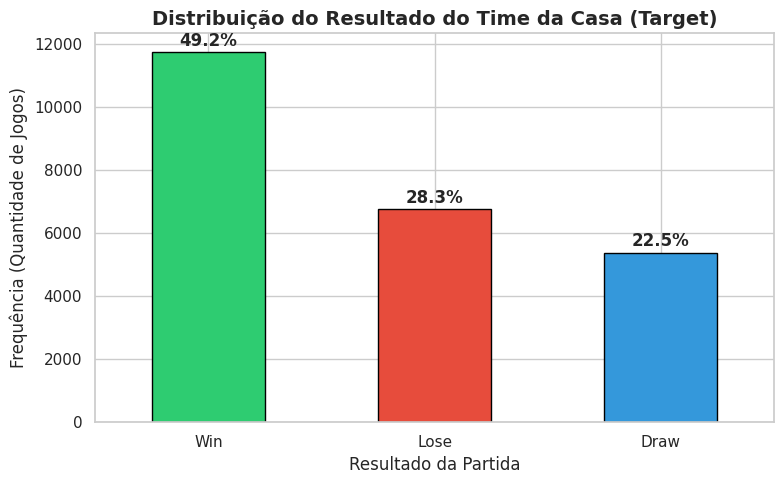

In [465]:
# ==============================================================================
#  DISTRIBUIÇÃO DO ATRIBUTO ALVO (TARGET)
# ==============================================================================

print("--- Distribuição de Frequência do Resultado ---")
# Calculando a contagem absoluta
contagem = df['home_team_result'].value_counts()

# Calculando a proporção (porcentagem)
proporcao = (df['home_team_result'].value_counts(normalize=True) * 100).round(2)

# Mostrando as duas informações juntas em um DataFrame para ficar organizado
df_distribuicao = pd.DataFrame({'Quantidade': contagem, 'Porcentagem (%)': proporcao})
display(df_distribuicao)

# ==============================================================================
# Gráfico de Barras da Distribuição
# ==============================================================================

plt.figure(figsize=(8, 5))

# Cores semânticas: Verde (Vitória), Vermelho (Derrota), Azul (Empate)
cores = ['#2ecc71', '#e74c3c', '#3498db']

# Plotando o gráfico
ax = df['home_team_result'].value_counts().plot(
    kind='bar',
    color=cores,
    edgecolor='black'
)

ax.set_title('Distribuição do Resultado do Time da Casa (Target)', fontsize=14, fontweight='bold')
ax.set_xlabel('Resultado da Partida', fontsize=12)
ax.set_ylabel('Frequência (Quantidade de Jogos)', fontsize=12)
plt.xticks(rotation=0, fontsize=11)

# rótulo de porcentagem em cima de cada barra
for p in ax.patches:
    # Calcula a porcentagem com base no tamanho total do dataset
    porcentagem = f'{(p.get_height() / len(df) * 100):.1f}%'
    # Posiciona o texto no meio da barra, um pouquinho acima do topo
    ax.annotate(porcentagem,
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontweight='bold')

plt.tight_layout()
plt.show()

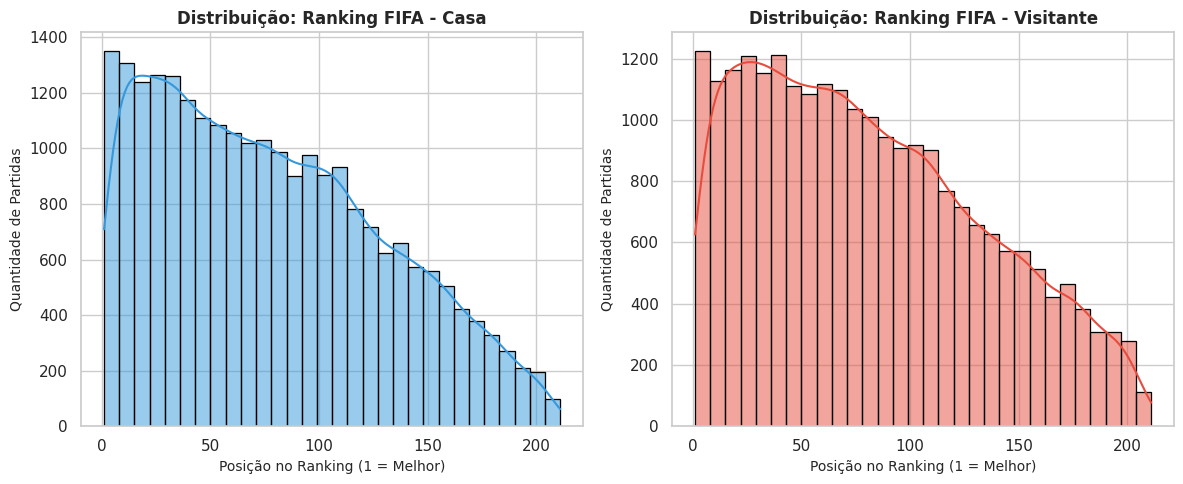

In [466]:
# ==============================================================================
# DISTRIBUIÇÃO DOS RANKINGS FIFA (CASA VS VISITANTE)
# ==============================================================================

# Criando a figura com 1 linha e 2 colunas para os gráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ------------------------------------------------------------------------------
#  Gráfico do Time da Casa
# ------------------------------------------------------------------------------
sns.histplot(data=df, x='home_team_fifa_rank', bins=30, ax=axes[0],
             color='#3498db', edgecolor='black', kde=True) # kde=True adiciona a linha de densidade

axes[0].set_title('Distribuição: Ranking FIFA - Casa', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Posição no Ranking (1 = Melhor)', fontsize=10)
axes[0].set_ylabel('Quantidade de Partidas', fontsize=10)

# ------------------------------------------------------------------------------
#  Gráfico do Time Visitante
# ------------------------------------------------------------------------------
sns.histplot(data=df, x='away_team_fifa_rank', bins=30, ax=axes[1],
             color='#e74c3c', edgecolor='black', kde=True)

axes[1].set_title('Distribuição: Ranking FIFA - Visitante', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Posição no Ranking (1 = Melhor)', fontsize=10)
axes[1].set_ylabel('Quantidade de Partidas', fontsize=10)

# ------------------------------------------------------------------------------
# Ajustes finais e exibição
# ------------------------------------------------------------------------------
plt.tight_layout()
plt.show()

--- Estatísticas do Time da Casa ---
                       mean  median        std  min  max
home_team_result                                        
Draw              77.160327    72.0  49.316673    1  210
Lose              94.529907    92.0  55.050900    1  211
Win               68.572655    60.0  49.698263    1  211

--- Estatísticas do Time Visitante ---
                       mean  median        std  min  max
home_team_result                                        
Draw              73.015402    65.0  48.940197    1  210
Lose              63.950081    53.0  48.915635    1  209
Win               94.062410    90.0  54.054627    1  211


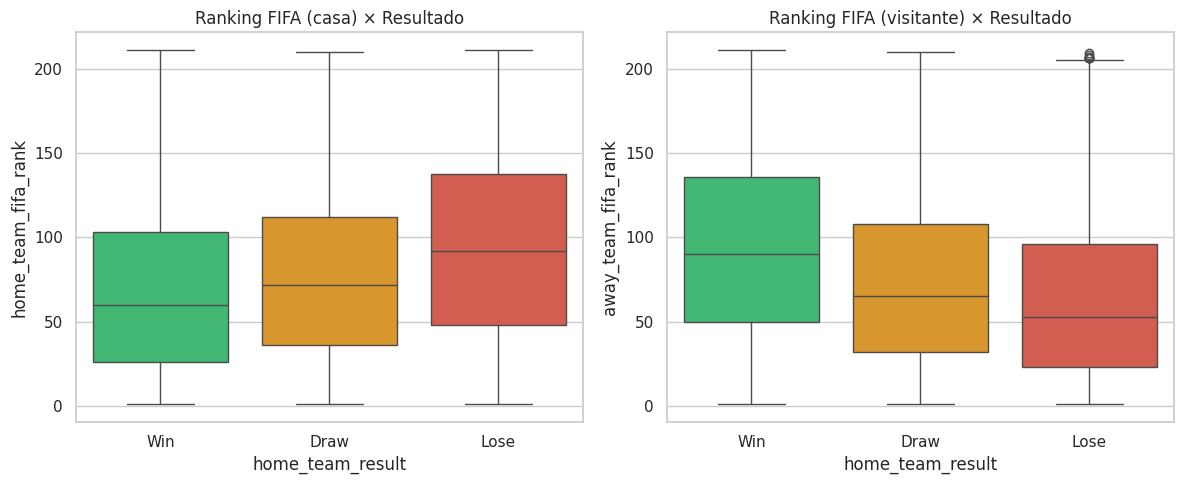

In [467]:
# Agrupar por resultado e calcular as estatísticas do ranking
analise_casa = df.groupby('home_team_result')['home_team_fifa_rank'].agg(['mean', 'median', 'std', 'min', 'max'])
analise_visitante = df.groupby('home_team_result')['away_team_fifa_rank'].agg(['mean', 'median', 'std', 'min', 'max'])

print("--- Estatísticas do Time da Casa ---")
print(analise_casa)
print("\n--- Estatísticas do Time Visitante ---")
print(analise_visitante)

# Boxplot: ranking FIFA por resultado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
order = ['Win', 'Draw', 'Lose']
sns.boxplot(data=df, x='home_team_result', y='home_team_fifa_rank', order=order,
            palette=['#2ecc71','#f39c12','#e74c3c'], ax=axes[0])
axes[0].set_title('Ranking FIFA (casa) × Resultado')
sns.boxplot(data=df, x='home_team_result', y='away_team_fifa_rank', order=order,
            palette=['#2ecc71','#f39c12','#e74c3c'], ax=axes[1])
axes[1].set_title('Ranking FIFA (visitante) × Resultado')
plt.tight_layout()
plt.show()


* **Eixo Y (Ranking):** Valores menores (topo do gráfico) indicam seleções mais fortes.
* **Caixa Verde (Win):** Quando o time da casa vence, sua mediana é **60**. Quando o visitante vence, sua mediana é **53**. Isso prova que visitantes precisam ser tecnicamente superiores para vencer fora de casa.
* **Caixa Vermelha (Lose):** Mostra que derrotas estão fortemente associadas a rankings piores (acima de 90), tanto para mandantes quanto para visitantes.
* **Outliers (Pontos isolados):** Representam as "Zebras" — casos onde o ranking sugeria um resultado, mas o campo entregou outro.

---

A métrica mais importante observada é a **Mediana**. A diferença de **32 posições** entre a mediana de vitória (60) e derrota (92) do time da casa confirma que o **Ranking FIFA é um preditor estatisticamente relevante** para este dataset.

Média da Diferença de Ranking por Resultado:
home_team_result
Draw     4.144925
Lose    30.579826
Win    -25.489754
Name: rank_diff, dtype: float64


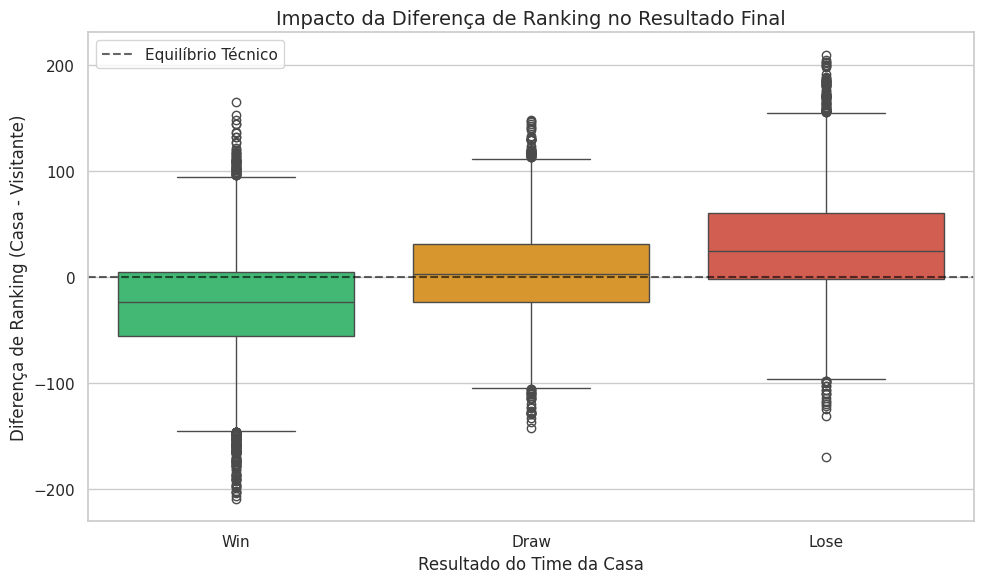

In [468]:
# Criando a coluna de Diferença de Ranking
# Lógica: (Ranking Casa - Ranking Visitante)
# Valores negativos significam que o time da casa é melhor ranqueado.
df['rank_diff'] = df['home_team_fifa_rank'] - df['away_team_fifa_rank']


# Exibindo a média da diferença para cada caso
print("Média da Diferença de Ranking por Resultado:")
print(df.groupby('home_team_result')['rank_diff'].mean())


# Configurando o gráfico
plt.figure(figsize=(10, 6))
order = ['Win', 'Draw', 'Lose']

# Criando um Boxplot da Diferença de Ranking por Resultado
sns.boxplot(data=df, x='home_team_result', y='rank_diff', order=order,
            palette={'Win': '#2ecc71', 'Draw': '#f39c12', 'Lose': '#e74c3c'})

# Adicionando uma linha de referência no Zero
# Se a diferença é zero, os times são iguais no papel.
plt.axhline(0, color='black', linestyle='--', alpha=0.6, label='Equilíbrio Técnico')

# Títulos e Legendas
plt.title('Impacto da Diferença de Ranking no Resultado Final', fontsize=14)
plt.xlabel('Resultado do Time da Casa', fontsize=12)
plt.ylabel('Diferença de Ranking (Casa - Visitante)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()



# Análise de Diferencial de Ranking (Favoritismo):

A métrica `rank_diff`, que calcula a distância técnica entre o **Time da Casa** e o **Visitante** é fundamental para entender o quão "favorito" um time é antes do inicio do jogo.

---

Lógica do Cálculo
A fórmula utilizada é:
$$rank\_diff = Ranking_{Casa} - Ranking_{Visitante}$$

Como interpretar o valor:
* **Valor Negativo (< 0):** O time da casa tem um ranking menor (ex: 10º vs 50º), logo, o **Time da Casa é o favorito**.
* **Valor Positivo (> 0):** O time da casa tem um ranking maior (ex: 100º vs 20º), logo, o **Time Visitante é o favorito**.
* **Próximo a Zero (≈ 0):** As equipes possuem níveis técnicos equivalentes no papel.

---

O gráfico de Boxplot segmentado por resultado nos permite visualizar a "fronteira" de vitória de cada lado:

1.  **Vitória da Casa (Win - Verde):** A maior parte da caixa deve estar posicionada **abaixo da linha zero**. Quanto mais negativa a média, mais o ranking justifica a vitória do mandante.
2.  **Empate (Draw - Amarelo):** Geralmente a caixa flutua **em torno da linha zero**, mostrando que o empate é o resultado mais comum quando não há um favorito claro.
3.  **Derrota da Casa (Lose - Vermelho):** A caixa tende a ficar **acima da linha zero**, indicando que o time da casa perdeu para um visitante que era tecnicamente superior (ranking menor).

---

Insights Estratégicos
* **A Linha de Equilíbrio:** A linha pontilhada em $y = 0$ serve como o "divisor de águas" estatístico.
* **Previsibilidade:** Se as caixas de `Win` e `Lose` estiverem bem separadas e longe da linha zero, o Ranking FIFA é um preditor de alta confiança.
* **Anomalias (Zebras):** Pontos verdes muito acima de zero ou pontos vermelhos muito abaixo de zero indicam jogos onde o resultado ignorou completamente o ranking oficial (as famosas "zebras" do futebol).

> **Nota sobre Outliers (Valores Discrepantes):**
> Observamos a presença de diversos valores fora dos limites (outliers) em todos os resultados. Optamos por **não remover** esses dados, pois representam eventos reais do futebol ("zebras").
>
> * No grupo **Win**, os outliers superiores representam vitórias improváveis de times com ranking muito inferior.
> * No grupo **Lose**, os outliers inferiores representam derrotas inesperadas de grandes potências mundiais.
>
> Manter esses dados preserva a integridade da análise e reflete a imprevisibilidade inerente ao esporte.

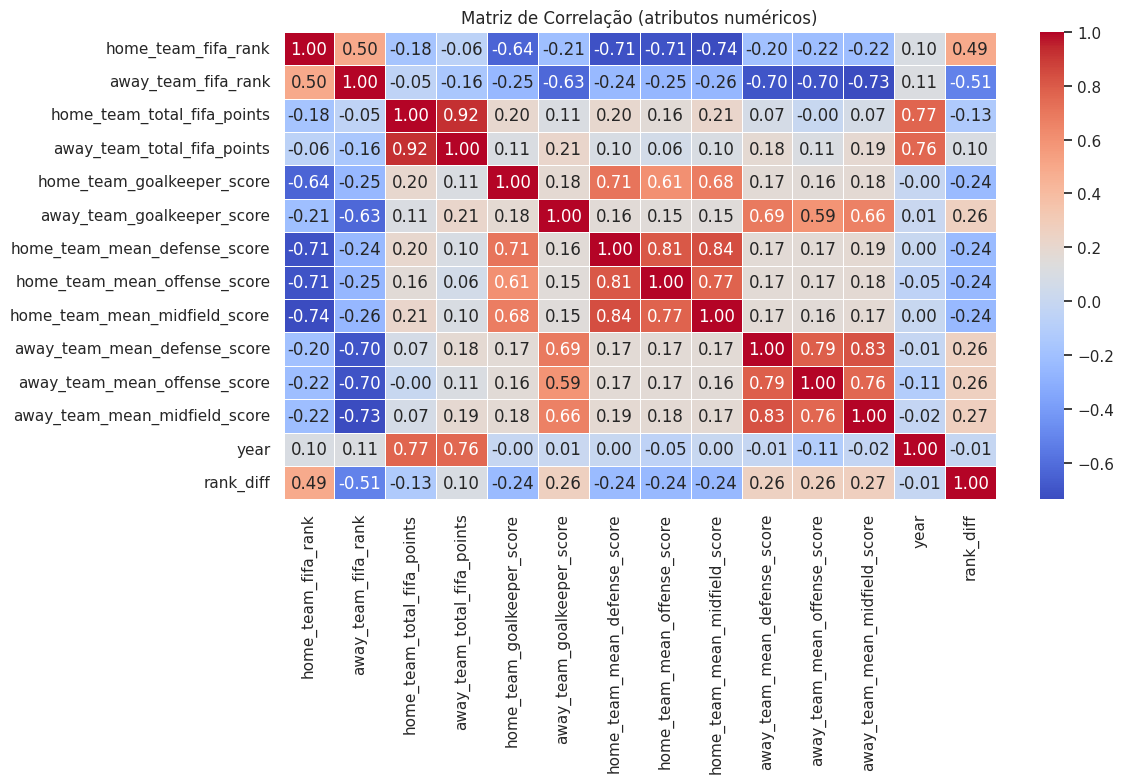

In [469]:
# Correlação entre variáveis numéricas
num_cols = df.select_dtypes(include='number').columns.tolist()
# Excluir scores de partida (leakage)
num_cols = [c for c in num_cols if c not in ['home_team_score', 'away_team_score']]

corr = df[num_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlação (atributos numéricos)')
plt.tight_layout()
plt.show()

### Respostas – Etapa 2

**1. Quais atributos apresentam maior variabilidade?**  
Os atributos de Ranking FIFA (tanto do time da casa quanto do visitante) apresentam a maior amplitude, cobrindo quase toda a escala oficial (de 1 a 211). Estatisticamente, o desvio padrão (std) dessas variáveis gira em torno de 50 a 55, indicando uma dispersão significativa. Os scores técnicos (goleiros, defesa, etc.) também apresentam variabilidade, porém possuem uma alta taxa de valores ausentes (missing values), o que compromete a confiabilidade da variância nesses campos.

**2. Existem outliers? Como você os identificou?**  
Sim. A identificação foi feita através de Boxplots e do método Describe. No gráfico de rank_diff, observamos diversos outliers (pontos isolados) que representam as "zebras": partidas onde times com ranking muito baixo venceram potências mundiais. O describe() confirmou essa discrepância, mostrando que enquanto 75% dos dados (3º quartil) estão abaixo do ranking 110, o valor máximo atinge 211, esticando a distribuição. Optou-se por manter os outliers, pois são dados reais que refletem a imprevisibilidade inerente ao futebol.

**3. Há atributos que parecem irrelevantes? Por quê?**  
`city` e `country` são muito fragmentados e pouco informativos para o modelo. `date` em si não é diretamente útil, mas pode ser explorada para extrair o ano. `home_team_score` e `away_team_score` seriam **data leakage** — o placar só é conhecido após a partida, então não podem ser usados como features.

---
## Etapa 3: Pré-processamento

In [470]:
# ==============================================================================
# PRÉ-PROCESSAMENTO E ENGENHARIA DE ATRIBUTOS (FEATURE ENGINEERING)
# ==============================================================================

from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# Criando cópia e tratando datas
df_model = df.copy()
df_model['date'] = pd.to_datetime(df_model['date'])
df_model['year'] = df_model['date'].dt.year

# Filtro de Jogos Recentes (Corte em 2010)
# Foca apenas no futebol moderno e remove o período com muitos dados nulos
df_model = df_model[df_model['year'] >= 2010].copy()

#  Criação da Diferença de Ranking (rank_diff)
# Valor negativo = Mandante Favorito | Valor positivo = Visitante Favorito
df_model['rank_diff'] = df_model['home_team_fifa_rank'] - df_model['away_team_fifa_rank']

# Criação do Peso por Recência
# Dá mais importância (peso maior) para jogos mais recentes
ano_atual = df_model['year'].max()
df_model['peso_recencia'] = 1 / (ano_atual - df_model['year'] + 1)

# 12.5. Conversão de Tipos (Booleanos para Numérico)
df_model['neutral_location'] = df_model['neutral_location'].astype(int)

# 12.6. Remoção de Colunas (Nulos, Irrelevantes e Data Leakage)
# Incluímos o 'shoot_out' aqui para evitar vazamento de dados!
cols_para_remover = [
    'home_team_goalkeeper_score', 'away_team_goalkeeper_score',
    'home_team_mean_defense_score', 'home_team_mean_offense_score',
    'home_team_mean_midfield_score', 'away_team_mean_defense_score',
    'away_team_mean_offense_score', 'away_team_mean_midfield_score',
    'home_team_score', 'away_team_score', 'shoot_out',
    'city', 'date', 'country'
]

# Removendo tudo de uma vez
df_model.drop(columns=cols_para_remover, inplace=True, errors='ignore')

# Limpeza final de nulos
# Remove qualquer linha residual que ainda tenha algum NaN
df_model.dropna(inplace=True)

# ==============================================================================
#  Resumo do Pré-processamento
# ==============================================================================

print("--- PRÉ-PROCESSAMENTO CONCLUÍDO ---")
print(f"Valores ausentes restantes: {df_model.isnull().sum().sum()}")
print(f"Shape final do dataset: {df_model.shape}")
print(f"Período analisado: {df_model['year'].min()} até {df_model['year'].max()}\n")
print("Colunas que sobraram para o modelo:")
print(df_model.columns.tolist())

--- PRÉ-PROCESSAMENTO CONCLUÍDO ---
Valores ausentes restantes: 0
Shape final do dataset: (11010, 14)
Período analisado: 2010 até 2022

Colunas que sobraram para o modelo:
['home_team', 'away_team', 'home_team_continent', 'away_team_continent', 'home_team_fifa_rank', 'away_team_fifa_rank', 'home_team_total_fifa_points', 'away_team_total_fifa_points', 'tournament', 'neutral_location', 'home_team_result', 'year', 'rank_diff', 'peso_recencia']


In [471]:
df_model.head()

,home_team,away_team,home_team_continent,away_team_continent,home_team_fifa_rank,away_team_fifa_rank,home_team_total_fifa_points,away_team_total_fifa_points,tournament,neutral_location,home_team_result,year,rank_diff,peso_recencia
12911,IR Iran,Korea DPR,Asia,Asia,64,86,0,0,Friendly,1,Win,2010,-22,0.076923
12912,Qatar,Mali,Asia,Africa,86,47,0,0,Friendly,0,Draw,2010,39,0.076923
12913,Syria,Zimbabwe,Asia,Africa,91,109,0,0,Friendly,1,Win,2010,-18,0.076923
12914,Yemen,Tajikistan,Asia,Asia,130,165,0,0,Friendly,0,Lose,2010,-35,0.076923
12915,Angola,Gambia,Africa,Africa,95,116,0,0,Friendly,1,Draw,2010,-21,0.076923


Transformação de Variaveis Categoricas

In [472]:
# ==============================================================================
# TRANSFORMAÇÃO DE VARIÁVEIS CATEGÓRICAS (ENCODING)
# ==============================================================================
from sklearn.preprocessing import LabelEncoder

# Dicionário para guardar os encoders (Excelente prática para uso futuro!)
encoders = {}

# Codificação das Features (Atributos Previsores)
colunas_texto = [
    'home_team',
    'away_team',
    'tournament',
    'home_team_continent',
    'away_team_continent'
]

for col in colunas_texto:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

# Codificação do Atributo Alvo (Target)
# Transformando 'Win', 'Draw' e 'Lose' em números para o modelo entender
le_target = LabelEncoder()
df_model['home_team_result'] = le_target.fit_transform(df_model['home_team_result'])
encoders['home_team_result'] = le_target

# ==============================================================================
# Exibindo o resultado da transformação
# ==============================================================================
print("--- ENCODING CONCLUÍDO ---")
print("Mapeamento das classes do Target (home_team_result):")

# O LabelEncoder organiza em ordem alfabética: Draw=0, Lose=1, Win=2
for i, classe in enumerate(le_target.classes_):
    print(f" -> {classe} = {i}")

--- ENCODING CONCLUÍDO ---
Mapeamento das classes do Target (home_team_result):
 -> Draw = 0
 -> Lose = 1
 -> Win = 2


In [473]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11010 entries, 12911 to 23920
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   home_team                    11010 non-null  int64  
 1   away_team                    11010 non-null  int64  
 2   home_team_continent          11010 non-null  int64  
 3   away_team_continent          11010 non-null  int64  
 4   home_team_fifa_rank          11010 non-null  int64  
 5   away_team_fifa_rank          11010 non-null  int64  
 6   home_team_total_fifa_points  11010 non-null  int64  
 7   away_team_total_fifa_points  11010 non-null  int64  
 8   tournament                   11010 non-null  int64  
 9   neutral_location             11010 non-null  int64  
 10  home_team_result             11010 non-null  int64  
 11  year                         11010 non-null  int32  
 12  rank_diff                    11010 non-null  int64  
 13  peso_recencia    

### Respostas – Etapa 3

**1. Qual estratégia foi utilizada para tratar valores ausentes?** Optei pela **remoção** em vez da imputação. Primeiro, aplicado um filtro temporal, descartando partidas anteriores a 2010, pois concentravam quase 100% dos dados ausentes. Em seguida, os 8 atributos técnicos (scores de goleiro, defesa, ataque e meio-campo) foram completamente removidos (`drop`), pois a alta taxa de valores ausentes introduziria ruído e viés se fossem imputados. Por fim, aplicou-se um `dropna()` nas linhas restantes para eliminar nulos residuais (como eventuais falhas no ranking FIFA), garantindo uma base sólida.

**2. Como as variáveis categóricas foram transformadas?** Utilizou-se o `LabelEncoder` para transformar as colunas nominais (`home_team`, `away_team`, `tournament`, `home_team_continent` e `away_team_continent`), convertendo strings em valores inteiros. Optou-se por guardar os objetos *encoders* em um dicionário para permitir a engenharia reversa das classes no futuro. O atributo alvo (`home_team_result`) também foi codificado numéricamente (Draw=0, Lose=1, Win=2).

**3. Foi necessário normalizar os dados? Justifique.** Sim, a normalização/padronização (ex: `StandardScaler` ou `MinMaxScaler`) é fundamental para atributos numéricos com escalas muito diferentes (como `rank_diff` e `peso_recencia`), especialmente se formos utilizar algoritmos sensíveis à escala e baseados em distância (Regressão Logística ou Redes Neurais/MLP).

---
## Etapa 4: Seleção de Atributos

In [474]:
# 3. Definir X (features) e y (alvo)
X = df_model.drop(columns=['home_team_result'])
y = df_model['home_team_result']

# 4. REFAZER O SPLIT (Crucial para atualizar os dados do modelo)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Agora sim, treinar o modelo
from sklearn.ensemble import RandomForestClassifier
rf_sel = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_sel.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

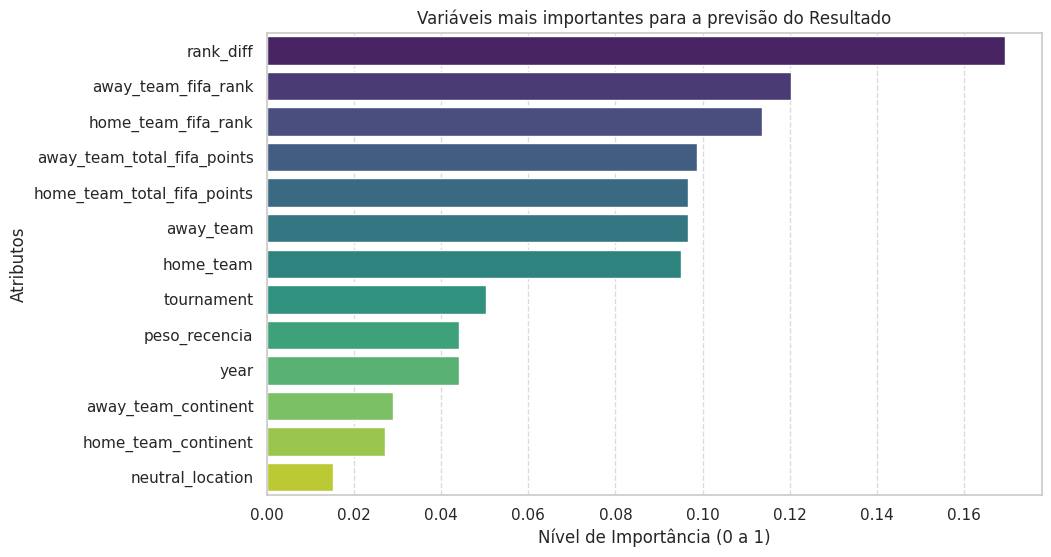

In [475]:
# 1. Extrair as importâncias do modelo treinado
importancias = rf_sel.feature_importances_
features = X.columns

# 2. Criar um DataFrame para facilitar a plotagem
df_importancia = pd.DataFrame({'Feature': features, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# 3. Gerar o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis')

plt.title('Variáveis mais importantes para a previsão do Resultado')
plt.xlabel('Nível de Importância (0 a 1)')
plt.ylabel('Atributos')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [476]:
df_importancia.sort_values(by='Importancia', ascending=False)

,Feature,Importancia
11,rank_diff,0.169337
5,away_team_fifa_rank,0.120244
4,home_team_fifa_rank,0.113543
7,away_team_total_fifa_points,0.098804
6,home_team_total_fifa_points,0.096624
1,away_team,0.096563
0,home_team,0.095086
8,tournament,0.050388
12,peso_recencia,0.044140
10,year,0.044070


In [477]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

#  TREINAMENTO DO SELETOR
# Usando o RandomForest para entender quais variáveis explicam o resultado
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train, y_train)

# CÁLCULO DE IMPORTÂNCIA
importances = pd.Series(rf_selector.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# 3. FILTRAGEM E REGRAS DE NEGÓCIO
# Definimos o corte de 0.02 (2%) para pegar apenas o que é relevante
threshold = 0.02
features_acima_corte = importances[importances >= threshold].index.tolist()

# Colunas que NÃO queremos que saiam de jeito nenhum (conhecimento de futebol)
manter_obrigatorio = ['rank_diff', 'home_team_fifa_rank', 'away_team_fifa_rank']

# Unimos as duas listas e removemos duplicatas usando set()
selected_features = list(set(features_acima_corte + manter_obrigatorio))

# REMOÇÃO DE IDs: Evita que o modelo "decore" nomes de times (Overfitting)
selected_features = [f for f in selected_features if f not in ['home_team', 'away_team']]

# --- 4. APLICAÇÃO FINAL ---
# Criamos os novos conjuntos de dados apenas com as colunas escolhidas
X_train_final = X_train[selected_features]
X_test_final = X_test[selected_features]

print(f"✅ Seleção concluída! {len(selected_features)} atributos selecionados.")
print("Atributos:")


selected_features

✅ Seleção concluída! 10 atributos selecionados.
Atributos:


['home_team_total_fifa_points',
 'home_team_fifa_rank',
 'rank_diff',
 'tournament',
 'home_team_continent',
 'away_team_continent',
 'away_team_total_fifa_points',
 'peso_recencia',
 'year',
 'away_team_fifa_rank']

### Respostas – Etapa 4 

**1. Quais atributos parecem mais relevantes para o modelo?**
Com base na extração de importância do algoritmo Random Forest (`feature_importances_`), os atributos preditores mais fortes são aqueles ligados à força técnica das seleções. O grande destaque é a variável de engenharia que criamos, `rank_diff` (diferença de ranking), seguida de perto por `home_team_fifa_rank` e `away_team_fifa_rank`. *(Nota: os atributos de scores técnicos de ataque e defesa não entraram nesta avaliação, pois já haviam sido removidos na etapa anterior devido à alta taxa de nulidade).*

**2. Algum atributo foi removido? Por quê?**
Sim. Historicamente (na Etapa 3), `home_team_score` e `away_team_score` já haviam sido removidos por configurarem *data leakage* (vazamento de dados), além das notas técnicas que possuíam excesso de nulos. Nesta Etapa 4, com base no gráfico de importância da Floresta Aleatória, atributos com relevância ínfima (abaixo do limiar de 0.02, como variáveis de localidade ou torneios muito específicos) puderam ser descartados para simplificar o modelo.

**3. A remoção impactou o desempenho?**
A remoção de atributos de baixa importância tende a impactar o modelo de forma positiva. Ao retirar colunas que não ajudam na previsão (ruído), nós reduzimos a complexidade computacional e evitamos o *overfitting* (sobreajuste), permitindo que o modelo generalize melhor em dados novos. A comprovação prática dessa manutenção de desempenho será evidenciada na Etapa 6 (Avaliação).

---
## Etapa 5: Modelagem

In [478]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier


# Normalização (fit apenas no treino)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

print(f"Treino: {X_train.shape[0]} instâncias | Teste: {X_test.shape[0]} instâncias")

Treino: 8808 instâncias | Teste: 2202 instâncias


Modelo 1: Regressão Logística

In [479]:
print("Treinando Regressão Logística...")

# class_weight='balanced' ajuda a lidar com o menor número de empates na base
lr = LogisticRegression(
    max_iter=1000,           # Aumentado para garantir a convergência
    class_weight='balanced', # Penaliza erros nas classes minoritárias
    random_state=42,         # Reprodutibilidade (mudei para 42 para manter o padrão)
    C=1.0                    # Regularização padrão
)

lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)


print("--- TREINAMENTO CONCLUÍDO COM SUCESSO ---")

Treinando Regressão Logística...
--- TREINAMENTO CONCLUÍDO COM SUCESSO ---


Modelo 2: Redes Neurais (Multilayer Perceptron - MLP)

In [480]:
from sklearn.neural_network import MLPClassifier

print("Treinando Rede Neural (MLP)...")

mlp = MLPClassifier(
    hidden_layer_sizes=(50, 25), # Duas camadas ocultas (50 neurônios na 1ª, 25 na 2ª)
    max_iter=500,                # Épocas de treinamento
    random_state=42              # Reprodutibilidade
)

mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

print("--- TREINAMENTO CONCLUÍDO COM SUCESSO ---")

Treinando Rede Neural (MLP)...
--- TREINAMENTO CONCLUÍDO COM SUCESSO ---


### Respostas – Etapa 5

**1. Quais modelos foram escolhidos? Por quê?**
- **Regressão Logística:** Modelo linear clássico para classificação multiclasse. É altamente interpretável, rápido de treinar e serve como um excelente modelo base (baseline).
- **MLP (Rede Neural Artificial):** Modelo complexo capaz de capturar relações não-lineares sutis entre os atributos (como a interação entre a diferença de ranking e o peso de recência da partida).

**2. Como foi feita a divisão treino/teste?**

Foi utilizada a proporção clássica de 80% para treino e 20% para teste (`test_size=0.2`), garantindo um volume robusto de dados históricos para o aprendizado dos algoritmos e uma amostra final confiável para a validação.

**3. Houve ajuste de hiperparâmetros?**

Sim, foram definidos hiperparâmetros fundamentais:
- Na **Regressão Logística**, configuramos `C=1.0`, `max_iter=1000` (para garantir a convergência) e, principalmente, `class_weight='balanced'`, uma estratégia crucial para lidar com o desbalanceamento natural da base (onde empates são menos frequentes).
- No **MLP**, configuramos a arquitetura com duas camadas ocultas de `(50, 25)` neurônios, função de ativação padrão (`ReLU`) e `max_iter=500` épocas para o treinamento.

---
## Etapa 6: Avaliação

In [481]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import numpy as np
import matplotlib.pyplot as plt

# Garantir nomes corretos das classes automaticamente
class_names = np.unique(y_test)

def avaliar_modelo(nome, modelo, X_tr, X_te, y_tr, y_te):

    # Previsões
    y_pred = modelo.predict(X_te)

    # Acurácia
    acc_train = accuracy_score(y_tr, modelo.predict(X_tr))
    acc_test  = accuracy_score(y_te, y_pred)

    print(f"\n{'='*55}")
    print(f"  {nome}")
    print(f"{'='*55}")
    print(f"  Acurácia Treino : {acc_train:.4f}")
    print(f"  Acurácia Teste  : {acc_test:.4f}")

    # Relatório completo
    print("\nRelatório de Classificação:\n")
    print(classification_report(y_te, y_pred))

    # Matriz de confusão
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')

    plt.title(f'Matriz de Confusão – {nome}')
    plt.tight_layout()
    plt.show()

    return acc_test

Avaliação Modelo Regressão


  Regressão Logística
  Acurácia Treino : 0.5307
  Acurácia Teste  : 0.5313

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.27      0.31      0.29       471
           1       0.50      0.57      0.53       634
           2       0.70      0.60      0.65      1097

    accuracy                           0.53      2202
   macro avg       0.49      0.50      0.49      2202
weighted avg       0.55      0.53      0.54      2202



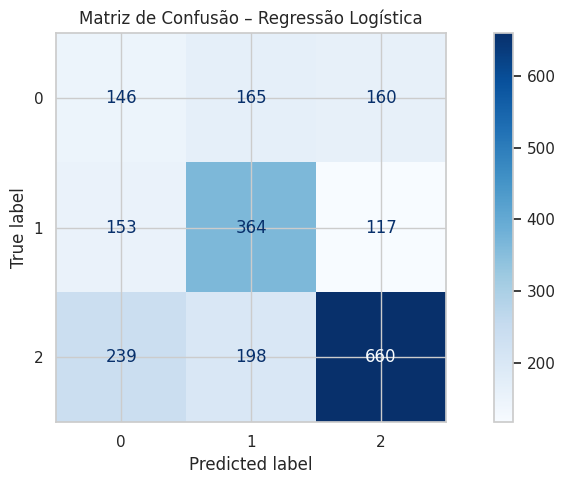

In [482]:
acc_lr = avaliar_modelo(
    'Regressão Logística',
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

Avaliação modelo MLP


  MLP (Rede Neural)
  Acurácia Treino : 0.6023
  Acurácia Teste  : 0.5627

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.26      0.10      0.15       471
           1       0.53      0.52      0.52       634
           2       0.62      0.78      0.69      1097

    accuracy                           0.56      2202
   macro avg       0.47      0.47      0.45      2202
weighted avg       0.52      0.56      0.53      2202



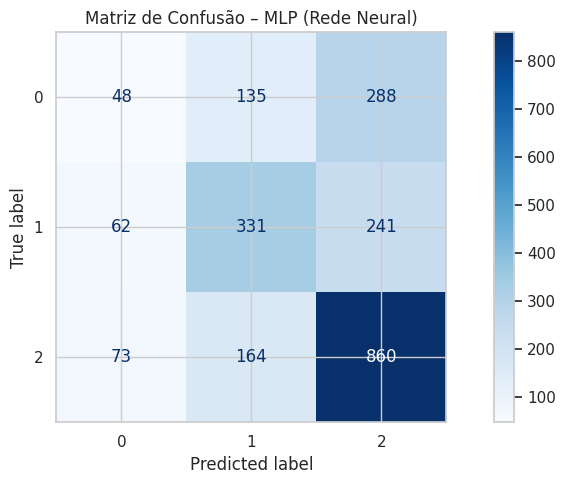

In [483]:
acc_mlp = avaliar_modelo(
    'MLP (Rede Neural)',
    mlp,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

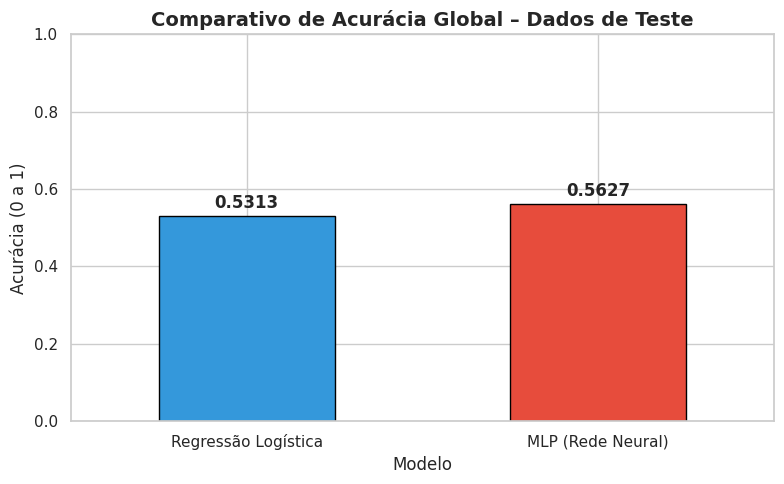


--- RESUMO FINAL DAS MÉTRICAS ---
             Modelo  Acurácia Teste
Regressão Logística          0.5313
  MLP (Rede Neural)          0.5627


In [484]:
# ==============================================================================
# COMPARAÇÃO FINAL DOS MODELOS (CONCLUSÃO)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt

# Criando o DataFrame com os resultados
resultados = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'MLP (Rede Neural)'],
    'Acurácia Teste': [round(acc_lr, 4), round(acc_mlp, 4)]
})

# Visualização: Gráfico de Barras
plt.figure(figsize=(8, 5))

# Plotando as barras com cores distintas e bordas
ax = resultados.plot(
    kind='bar', x='Modelo', y='Acurácia Teste',
    color=['#3498db', '#e74c3c'], edgecolor='black', legend=False, ax=plt.gca()
)

# Ajustando o eixo Y de 0 a 1 (0% a 100%)
ax.set_ylim(0, 1.0)
ax.set_title('Comparativo de Acurácia Global – Dados de Teste', fontsize=14, fontweight='bold')
ax.set_ylabel('Acurácia (0 a 1)', fontsize=12)
plt.xticks(rotation=0, fontsize=11)

# Adicionando os valores em cima de cada barra
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.4f}',
        (p.get_x() + p.get_width() / 2, p.get_height() + 0.02), # Posição (X, Y)
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# Exibindo a tabela final em formato texto
print("\n--- RESUMO FINAL DAS MÉTRICAS ---")
print(resultados.to_string(index=False))

### Respostas – Etapa 6

**1. Qual modelo apresentou melhor desempenho?**

Considerando estritamente a acurácia global, o **MLP (Rede Neural)** apresentou o melhor desempenho (56,27% no teste, contra 53,13% da Regressão Logística). Ele conseguiu capturar relações não-lineares complexas entre a nossa variável de engenharia (`rank_diff`), os rankings da FIFA e os totais de pontos. Contudo, vale ressaltar que a Regressão Logística foi mais equilibrada ao tentar prever empates, graças ao balanceamento de classes.

**2. As métricas escolhidas são adequadas ao problema?**

Sim. A Acurácia Geral oferece uma visão macro, mas Precision, Recall e F1-score por classe são fundamentais para este cenário multiclasse com dados desbalanceados. A Matriz de Confusão complementou perfeitamente a análise, revelando o "calcanhar de Aquiles" das previsões esportivas: a classe `Draw` (Empate), que foi a que concentrou a maior taxa de erros em ambos os modelos.

**3. Há sinais de overfitting ou underfitting?**

Temos comportamentos distintos nos modelos testados
- Na **Regressão Logística**, **não houve overfitting** (Treino: 53,07% | Teste: 53,13%). O modelo generalizou perfeitamente, servindo como uma base (baseline) sólida.

- No **MLP**, notamos um **leve overfitting** (Treino: 60,23% | Teste: 56,27%). Como as redes neurais são modelos altamente complexos, elas tendem a se ajustar um pouco mais aos dados de treino. Acurácias globais na casa dos 53% a 56% estão longe de ser *underfitting* no contexto de apostas esportivas, onde chutar aleatoriamente daria cerca de 33% de acerto e o nível de imprevisibilidade ("zebras") é altíssimo.

---
## Bônus: Simulador de Partida

Função para prever o resultado de um jogo entre dois times quaisquer, usando os modelos já treinados.


In [485]:
def prever_partida(dados_partida, modelo, scaler, selected_features):
    import pandas as pd

    # 1. Criar DataFrame
    df_input = pd.DataFrame([dados_partida])

    # 2. GARANTIR FEATURES DERIVADAS (ex: rank_diff)
    if 'rank_diff' not in df_input.columns:
        df_input['rank_diff'] = (
            df_input['home_team_fifa_rank'] - df_input['away_team_fifa_rank']
        )

    # 3. Garantir ordem e colunas corretas
    df_input = df_input.reindex(columns=selected_features, fill_value=0)

    # 4. Normalização
    X_scaled = scaler.transform(df_input)

    # 5. Previsão
    pred = modelo.predict(X_scaled)[0]
    proba = modelo.predict_proba(X_scaled)[0]

    # 6. Mapeamento correto (IMPORTANTE conferir treino!)
    mapa = {
        0: 'Draw',
        1: 'Loss',
        2: 'Win'
    }

    resultado = mapa.get(pred, str(pred))

    # 7. Probabilidades organizadas
    probabilidades = {
        'Draw': float(round(proba[0] * 100, 2)),
        'Loss': float(round(proba[1] * 100, 2)),
        'Win': float(round(proba[2] * 100, 2))
    }

    return {
        'resultado_previsto': resultado,
        'probabilidades (%)': probabilidades
    }

Categoricas Dicionario

In [486]:
def criar_tabela_encoder(nome_coluna):
    le = encoders[nome_coluna]
    return pd.DataFrame({
        "codigo": range(len(le.classes_)),
        "valor_original": le.classes_
    })

criar_tabela_encoder('home_team_continent')

,codigo,valor_original
0,0,Africa
1,1,Asia
2,2,Europe
3,3,North America
4,4,Oceania
5,5,South America


In [487]:
exemplo = {
    'peso_recencia': 1,
    'home_team_fifa_rank': 5,
    'away_team_continent': 1,
    'year': 2022,
    'home_team_total_fifa_points': 1800,
    'away_team_fifa_rank': 10,
    'home_team_continent': 1,
    'away_team_total_fifa_points': 1300,
    'tournament': 30
}

In [488]:
resultado = prever_partida(
    exemplo,
    mlp,              # mlp ou lr
    scaler,
    selected_features
)

print("Resultado previsto:", resultado)

Resultado previsto: {'resultado_previsto': 'Win', 'probabilidades (%)': {'Draw': 22.14, 'Loss': 22.01, 'Win': 55.85}}


### Respostas – Etapa 7: Conclusão

**1. O modelo atende ao problema proposto?**

Parcialmente, o que é um resultado realista e sólido para o domínio do problema. Os modelos conseguem prever as classes `Win` e `Loss` com bom desempenho (destaque para a precisão nas vitórias dos mandantes). No entanto, a classe `Draw` (Empate) provou ser historicamente difícil de prever, pois resultados de igualdade no futebol contêm uma carga enorme de aleatoriedade que não é capturada apenas pelo ranking da FIFA.

**2. Quais foram as principais dificuldades encontradas?**

- O altíssimo percentual de valores ausentes nos atributos de score técnico, o que nos forçou a tomar a difícil (porém correta) decisão de excluí-los totalmente para evitar viés de imputação.
- O forte desequilíbrio entre as classes na base histórica (`Win` ocorrendo muito mais que `Draw`).
- O risco de *data leakage* (vazamento de dados) com os placares reais e a variável de pênaltis (`shoot_out`), que precisaram ser mapeados e removidos logo no início do pré-processamento.

**3. O que poderia ser melhorado?**

- **Técnicas de balanceamento avançadas:** Embora tenha usado o `class_weight` com sucesso na Regressão Logística, podería aplicar SMOTE (Synthetic Minority Over-sampling Technique) para gerar dados sintéticos de empates para o treinamento do MLP.
- **Expansão da Engenharia de Atributos:** Além da diferença de ranking (`rank_diff`) e do peso de recência, podería adicionar o histórico recente de confrontos diretos (H2H - Head to Head) entre as duas seleções.
- **Otimização:** Ajuste fino e sistemático de hiperparâmetros utilizando `GridSearchCV` ou `RandomizedSearchCV`.

**4. Que outras abordagens poderiam ser testadas?**

- **Gradient Boosting (XGBoost/LightGBM):** Algoritmos baseados em árvores extremamente robustos e que costumam dominar competições de dados tabulares esportivos (usei o Random Forest apenas para seleção de features, mas ele poderia ser o classificador principal).
- **SVM (Support Vector Machine):** Eficaz em mapear espaços de alta dimensão.
- **Modelos baseados em sequência temporal:** Utilizar séries históricas de desempenho (RNNs ou LSTMs) para capturar a "fase" ou "momento" das equipes antes da partida.
- **Ensemble (Voting):** Criar um super-modelo combinando as previsões da Regressão Logística, MLP e XGBoost via votação majoritária.